In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Clean_Text_Youtube - clean_text_youtube.csv")
df

,S No.,Link,Upload Date,Views,Likes,Comments,Transcript/Transcript Link,Transcript_Cleaned
0,1,https://youtu.be/Z6LBZoNx9bw?si=P6X0-GY4Quvj84wP,Oct 2025,"2,541",57,11,It's just getting off at like 4:30 in the morn...,getting 430 morning sometimes 5 working overti...
1,2,https://youtu.be/bmvM_1yzB1g?si=U5h0VjCKZKfhmk9v,February 2026,1711,54,30,"After this 10-hour shift, I couldn't feel my l...",10 hour shift couldnt feel legs really think j...
2,3,https://youtu.be/MMrH90TzAvo?si=pWwp1Xnex1x6RJjd,Mar 2026,9,0,0,So if you do a job like picking where you hav...,job picking go around warehouse pick goods pur...
3,4,https://youtu.be/OremfN7DCXk?si=G1plTTnjxHk5uhHG,Jan 2025,4128,203,36,number three number three way to learn\nhow to...,number three number three way learn survive wo...
4,5,https://youtu.be/8oKUMyq9Wi0?si=O4R5UWAAMuxeiDlx,Nov 2021,5982,209,64,which i work okay so in our warehouse they rec...,work okay warehouse recently changed number pa...
5,6,https://youtu.be/_H2LuAJEd1M?si=kBaDSmLWOYO95zDE,April 2024,42,5,0,"So, pretty much whatdoing here,this is where a...",pretty much packers get items scanning items s...


In [ ]:
df['sentiment_polarity'] = df['Transcript_Cleaned'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['sentiment_subjectivity'] = df['Transcript_Cleaned'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [ ]:
def label_sentiment(score):
  if score > .1:
    return 'positive'
  elif score < .1:
    return 'negative'
  else:
    return 'neutral'

df['sentiment_label'] = df['sentiment_polarity'].apply(label_sentiment)
df

,S No.,Link,Upload Date,Views,Likes,Comments,Transcript/Transcript Link,Transcript_Cleaned,sentiment_polarity,sentiment_subjectivity,sentiment_label
0,1,https://youtu.be/Z6LBZoNx9bw?si=P6X0-GY4Quvj84wP,Oct 2025,"2,541",57,11,It's just getting off at like 4:30 in the morn...,getting 430 morning sometimes 5 working overti...,0.051562,0.291146,negative
1,2,https://youtu.be/bmvM_1yzB1g?si=U5h0VjCKZKfhmk9v,February 2026,1711,54,30,"After this 10-hour shift, I couldn't feel my l...",10 hour shift couldnt feel legs really think j...,-0.038889,0.377778,negative
2,3,https://youtu.be/MMrH90TzAvo?si=pWwp1Xnex1x6RJjd,Mar 2026,9,0,0,So if you do a job like picking where you hav...,job picking go around warehouse pick goods pur...,0.049471,0.438095,negative
3,4,https://youtu.be/OremfN7DCXk?si=G1plTTnjxHk5uhHG,Jan 2025,4128,203,36,number three number three way to learn\nhow to...,number three number three way learn survive wo...,0.123864,0.370581,positive
4,5,https://youtu.be/8oKUMyq9Wi0?si=O4R5UWAAMuxeiDlx,Nov 2021,5982,209,64,which i work okay so in our warehouse they rec...,work okay warehouse recently changed number pa...,0.183333,0.520833,positive
5,6,https://youtu.be/_H2LuAJEd1M?si=kBaDSmLWOYO95zDE,April 2024,42,5,0,"So, pretty much whatdoing here,this is where a...",pretty much packers get items scanning items s...,0.123326,0.527344,positive


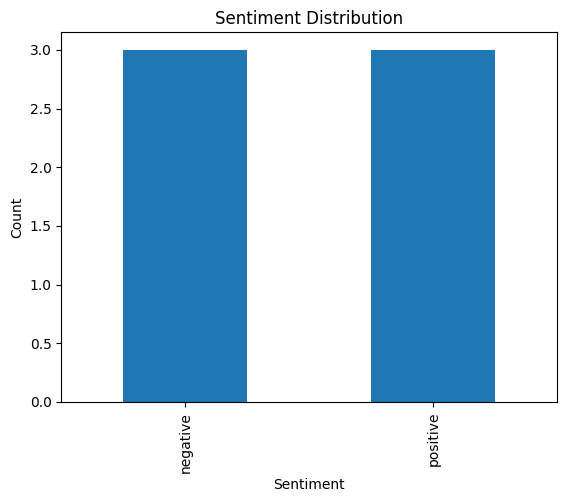

In [ ]:
df['sentiment_label'].value_counts().plot(kind='bar', title="Sentiment Distribution")
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

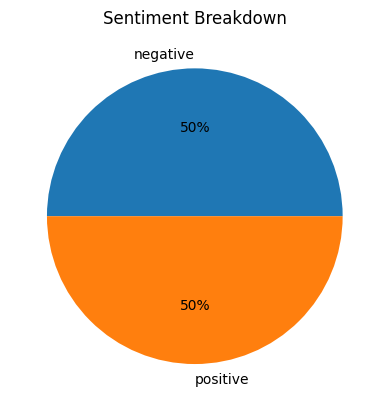

In [ ]:
df['sentiment_label'].value_counts().plot(
    kind='pie',
    autopct='%1.0f%%',
    title="Sentiment Breakdown"
)
plt.ylabel('')
plt.show()

In [ ]:
df.to_csv('Sentiment_Analysis_Youtube.csv')